# Ejecución y Validación del IAI

In [5]:
%load_ext autoreload
%autoreload 2
import sys
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.ticker as mticker
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr

#importamos motor logico del IAI
module_path = os.path.abspath(os.path.join('..')) 

if module_path not in sys.path:
    sys.path.append(module_path)
from src.IAI_estimador_V2 import calculate_iai, CROP_AGRONOMIC_SETTINGS


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
OUTPUT_DIR = "resultados_IAI"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path,dpi=300, bbox_inches="tight")
    print(f"  [guardado] {path}")
   

In [7]:
#Cargamos el Dataaset historico limpio
df_hist_clean = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_clean.parquet")
print("Filas totales:", df_hist_clean.shape[0])
print("Filas únicas (year, crop_id, lon, lat):",
      df_hist_clean
      .with_columns([
          pl.col("location").struct.field("coordinates").list.get(0).alias("lon"),
          pl.col("location").struct.field("coordinates").list.get(1).alias("lat")
      ])
      .select(["year", "crop_id", "lon", "lat"])
      .n_unique())

Filas totales: 633904
Filas únicas (year, crop_id, lon, lat): 633904


In [8]:
# Verificar activación del techo con el diferencial real (7.6)
df_check = df_hist_clean.with_columns(
    ((pl.col("tmax") + pl.col("tmin"))/2).alias("t_media")
)

print("Activación del techo del GDD por cultivo:\n")
for cid, params in CROP_AGRONOMIC_SETTINGS.items():
    techo = params["t_range"][2] - 7.6
    pct = 100 * (df_check["t_media"] > techo).mean()
    print(f"  {params['name']:14s}: óptimo_tmax={params['t_range'][2]:.0f}, "
          f"techo_media={techo:.1f}°C, parcelas>{techo:.0f}°C = {pct:.1f}%")

Activación del techo del GDD por cultivo:

  Almonds       : óptimo_tmax=35, techo_media=27.4°C, parcelas>27°C = 0.0%
  Cotton        : óptimo_tmax=36, techo_media=28.4°C, parcelas>28°C = 0.0%
  Grapes        : óptimo_tmax=30, techo_media=22.4°C, parcelas>22°C = 5.3%
  Pistachios    : óptimo_tmax=35, techo_media=27.4°C, parcelas>27°C = 0.0%
  Walnuts       : óptimo_tmax=30, techo_media=22.4°C, parcelas>22°C = 5.3%
  Tomatoes      : óptimo_tmax=27, techo_media=19.4°C, parcelas>19°C = 7.1%
  Rice          : óptimo_tmax=30, techo_media=22.4°C, parcelas>22°C = 5.3%
  Lettuce       : óptimo_tmax=21, techo_media=13.4°C, parcelas>13°C = 92.6%
  Strawberries  : óptimo_tmax=24, techo_media=16.4°C, parcelas>16°C = 73.6%
  Oranges       : óptimo_tmax=30, techo_media=22.4°C, parcelas>22°C = 5.3%
  Alfalfa       : óptimo_tmax=27, techo_media=19.4°C, parcelas>19°C = 7.1%
  Wheat         : óptimo_tmax=23, techo_media=15.4°C, parcelas>15°C = 88.6%


# Calcular Índice de Idoneidad Agroclimática (IAI)

In [9]:
# Aplicamos la función vectorizada 
df_iai_hist = calculate_iai(df_hist_clean)

# Extraemos los valores para graficar
iai_values = df_iai_hist["IAI"].to_numpy()

print(f" IAI calculado exitosamente para {len(iai_values):,} parcelas.")

 IAI calculado exitosamente para 633,904 parcelas.


  [guardado] resultados_IAI\hist_distribucion_iai.png


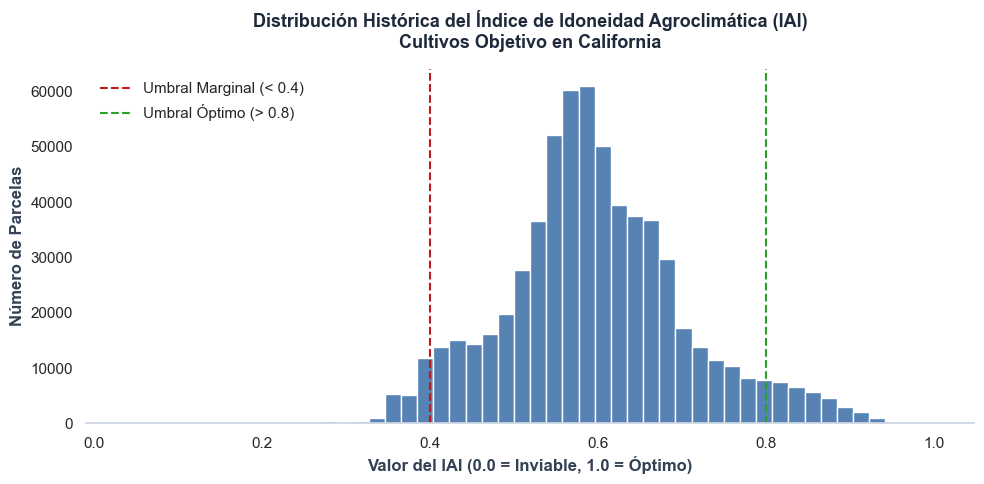

statistic,IAI
str,f64
"""count""",633904.0
"""null_count""",0.0
"""mean""",0.596347
"""std""",0.108565
"""min""",0.038889
"""25%""",0.534611
"""50%""",0.588327
"""75%""",0.657213
"""max""",1.0


In [10]:
# HISTOGRAMA DE VALIDACIÓN

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma con la paleta institucional
sns.histplot(iai_values, bins=50, color="#4374ac", edgecolor="white", alpha=0.9, ax=ax)

# Líneas de corte analítico
ax.axvline(0.4, color='#b91c1c', linestyle='--', linewidth=1.5, label='Umbral Marginal (< 0.4)')
ax.axvline(0.8, color='#2ca02c', linestyle='--', linewidth=1.5, label='Umbral Óptimo (> 0.8)')

# Estética
ax.set_title("Distribución Histórica del Índice de Idoneidad Agroclimática (IAI)\nCultivos Objetivo en California", 
             fontsize=13, fontweight="bold", pad=15, color="#1e293b")
ax.set_xlabel("Valor del IAI (0.0 = Inviable, 1.0 = Óptimo)", fontweight="bold", color="#334155")
ax.set_ylabel("Número de Parcelas", fontweight="bold", color="#334155")

ax.grid(False)
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#cbd5e1')
ax.legend(frameon=False)

plt.tight_layout()
save(fig, "hist_distribucion_iai.png")
plt.show()

# Resumen estadístico
display(df_iai_hist.select("IAI").describe())

In [15]:
# Componendes del IAI
pl.Config.set_tbl_rows(30)
# Calculamos la media de cada componente individual para toda California
componentes = df_iai_hist.select(["I_GDD", "I_temp", "I_precip", "I_suelo"]).mean()
display(componentes)

# Y para ver si el problema es general o de un cultivo en específico:
print("\n PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:")
display(df_iai_hist.group_by("crop_name").agg(pl.col("I_temp").mean()).sort("I_temp"))

# Y para ver si el problema es general o de un cultivo en específico:
print("\n PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:")
display(df_iai_hist.group_by("crop_name").agg(pl.col("IAI").mean()).sort("IAI"))

I_GDD,I_temp,I_precip,I_suelo
f64,f64,f64,f64
0.730182,0.913091,0.127594,0.585606



 PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:


crop_name,I_temp
str,f64
"""Lettuce""",0.113423
"""Wheat""",0.507872
"""Alfalfa""",0.906797
"""Pistachios""",0.980777
"""Strawberries""",0.994365
"""Oranges""",0.99748
"""Grapes""",0.99798
"""Tomatoes""",0.998851
"""Cotton""",0.999222



 PROMEDIO DEL ÍNDICE DE TEMPERATURA POR CULTIVO:


crop_name,IAI
str,f64
"""Lettuce""",0.364813
"""Cotton""",0.428301
"""Oranges""",0.463093
"""Rice""",0.553218
"""Grapes""",0.56518
"""Wheat""",0.567987
"""Tomatoes""",0.572039
"""Alfalfa""",0.600457
"""Strawberries""",0.652291


In [12]:
# Verificar de dónde vienen las 48 filas faltantes
print("Nulos por columna relevante:")
for col in ["tmax", "tmin", "ppt", "ph1to1h2o_r", "profundidad_efectiva_cm", "awc_r", "IAI"]:
    print(f"  {col}: {df_iai_hist.select(pl.col(col).is_null().sum()).item()}")

Nulos por columna relevante:
  tmax: 0
  tmin: 0
  ppt: 0
  ph1to1h2o_r: 0
  profundidad_efectiva_cm: 0
  awc_r: 0
  IAI: 0


In [13]:
print("Filas totales:", df_iai_hist.shape[0])
print("Filas únicas (year, crop_id, lon, lat):",
      df_iai_hist
      .with_columns([
          pl.col("location").struct.field("coordinates").list.get(0).alias("lon"),
          pl.col("location").struct.field("coordinates").list.get(1).alias("lat")
      ])
      .select(["year", "crop_id", "lon", "lat"])
      .n_unique())

Filas totales: 633904
Filas únicas (year, crop_id, lon, lat): 633904


In [14]:
df_iai_hist.write_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet")


In [10]:
import inspect
from src.IAI_estimador_V2 import calculate_iai
print(inspect.getsource(calculate_iai))

def calculate_iai(df):
    gdd_cases = pl.when(False).then(0.0)
    i_temp_cases = pl.when(False).then(0.0)
    i_precip_cases = pl.when(False).then(0.0)
    i_suelo_cases = pl.when(False).then(0.0)

    t_max_col = "tmax"
    t_min_col = "tmin"
    p_total_col = "ppt"

    DIAS_TEMPORADA = 200
    UMBRAL_GDD = 2500

    # Diferencial típico entre tmax y temperatura media en California.
    # Verifícalo en tus datos y ajusta este valor.
    DIFERENCIAL_TMAX_MEDIA = 8.0

    for crop_id, params in CROP_AGRONOMIC_SETTINGS.items():

        # --- I_GDD con TECHO en escala de temperatura MEDIA ---
        # El GDD acumula calor útil hasta la temperatura óptima de crecimiento.
        # Por encima de ese óptimo, el calor adicional NO incrementa la
        # idoneidad (el crecimiento no mejora e incluso sufre estrés térmico).
        #
        # El óptimo de temperatura de GAEZ (t_range[2]) está en escala de tmax.
        # Como el GDD usa temperatura media, se traslada ese óptimo a la escal

In [11]:
# ¿Qué fracción de parcelas ya tiene el GDD saturado en 1.0?
df_check = df_hist_clean.with_columns(
    ((pl.col("tmax") + pl.col("tmin")) / 2).alias("t_media")
)
# Para almendras (t_base 7.2): satura si t_media > 19.7
print("t_media histórica:")
print(f"  media: {df_check['t_media'].mean():.1f}")
print(f"  % parcelas con t_media > 19.7 (satura almendras): "
      f"{100*(df_check['t_media'] > 19.7).mean():.1f}%")
print(f"  % parcelas con t_media > 17.5 (satura alfalfa): "
      f"{100*(df_check['t_media'] > 17.5).mean():.1f}%")

t_media histórica:
  media: 17.0
  % parcelas con t_media > 19.7 (satura almendras): 6.9%
  % parcelas con t_media > 17.5 (satura alfalfa): 37.6%


In [25]:
# Comparar el I_GDD de la v1 (sin techo) vs v2 (con techo) directamente
# Recalcular con ambas versiones sobre las mismas parcelas

# Cargar las dos versiones del IAI ya calculadas
iai_v1 = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")
iai_v2 = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v2.parquet")
iai_v3 = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet")

# Comparar el I_GDD medio por cultivo entre las dos versiones
if "I_GDD" in iai_v1.columns and "I_GDD" in iai_v2.columns and "I_GDD" in iai_v2.columns:
    g1 = iai_v1.group_by("crop_id").agg(pl.col("I_GDD").mean().alias("gdd_v1"))
    g2 = iai_v2.group_by("crop_id").agg(pl.col("I_GDD").mean().alias("gdd_v2"))
    g3 = iai_v3.group_by("crop_id").agg(pl.col("I_GDD").mean().alias("gdd_v3"))
    comp = (
    g1.join(g2, on="crop_id")
    .join(g3, on="crop_id")
    .with_columns((pl.col("gdd_v3") - pl.col("gdd_v1")).alias("dif_gdd_v3_v1"))
    .sort("dif_gdd_v3_v1")
)

else:
    print("Una de las versiones no tiene la columna I_GDD guardada")
    print(f"Columnas v1: {[c for c in iai_v1.columns if 'GDD' in c or 'gdd' in c]}")
    print(f"Columnas v2: {[c for c in iai_v2.columns if 'GDD' in c or 'gdd' in c]}")
    print(f"Columnas v3: {[c for c in iai_v3.columns if 'GDD' in c or 'gdd' in c]}")


In [26]:
print(comp)


shape: (12, 5)
┌─────────┬──────────┬──────────┬──────────┬───────────────┐
│ crop_id ┆ gdd_v1   ┆ gdd_v2   ┆ gdd_v3   ┆ dif_gdd_v3_v1 │
│ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---           │
│ i64     ┆ f64      ┆ f64      ┆ f64      ┆ f64           │
╞═════════╪══════════╪══════════╪══════════╪═══════════════╡
│ 227     ┆ 0.988344 ┆ 0.67932  ┆ 0.711202 ┆ -0.277142     │
│ 221     ┆ 0.597896 ┆ 0.588203 ┆ 0.591464 ┆ -0.006431     │
│ 212     ┆ 0.401279 ┆ 0.399441 ┆ 0.400088 ┆ -0.00119      │
│ 54      ┆ 0.565535 ┆ 0.564992 ┆ 0.56538  ┆ -0.000155     │
│ 69      ┆ 0.549292 ┆ 0.548851 ┆ 0.549207 ┆ -0.000086     │
│ 36      ┆ 0.787491 ┆ 0.787491 ┆ 0.787491 ┆ -7.7716e-16   │
│ 204     ┆ 0.855731 ┆ 0.855731 ┆ 0.855731 ┆ -7.7716e-16   │
│ 2       ┆ 0.228121 ┆ 0.228121 ┆ 0.228121 ┆ -3.6082e-16   │
│ 24      ┆ 0.992243 ┆ 0.992243 ┆ 0.992243 ┆ -2.2204e-16   │
│ 76      ┆ 0.796811 ┆ 0.796811 ┆ 0.796811 ┆ 5.5511e-16    │
│ 3       ┆ 0.539115 ┆ 0.539115 ┆ 0.539115 ┆ 1.2212e-15    │
│ 75     

In [ ]:
# ══════════════════════════════════════════════════════
#  VERIFICACIÓN DEL SUBÍNDICE DE FRÍO (aislado)
#  Comprobar que penaliza a los frutales con el calentamiento
#  antes de integrarlo al índice completo
# ══════════════════════════════════════════════════════

import polars as pl

# Requerimientos de frío traducidos a umbrales de tmin anual
CHILL_SETTINGS = {
    76:  {"name": "Walnuts",      "chill": "alto",     "tmin_opt": 8.0,  "tmin_max": 12.0},
    204: {"name": "Pistachios",   "chill": "alto",     "tmin_opt": 8.5,  "tmin_max": 12.5},
    75:  {"name": "Almonds",      "chill": "moderado", "tmin_opt": 9.5,  "tmin_max": 13.5},
    69:  {"name": "Grapes",       "chill": "bajo",     "tmin_opt": 10.5, "tmin_max": 15.0},
    2:   {"name": "Cotton",       "chill": "ninguno"},
    54:  {"name": "Tomatoes",     "chill": "ninguno"},
    3:   {"name": "Rice",         "chill": "ninguno"},
    227: {"name": "Lettuce",      "chill": "ninguno"},
    221: {"name": "Strawberries", "chill": "ninguno"},
    212: {"name": "Oranges",      "chill": "ninguno"},
    36:  {"name": "Alfalfa",      "chill": "ninguno"},
    24:  {"name": "Wheat",        "chill": "ninguno"},
}

MIN_SUBINDICE = 0.3

def calcular_chill(tmin_series, crop_id):
    """Calcula el subíndice de frío para un cultivo dado una serie de tmin."""
    cfg = CHILL_SETTINGS[crop_id]
    if cfg["chill"] == "ninguno":
        return pl.Series([1.0] * len(tmin_series))

    t_opt = cfg["tmin_opt"]
    t_max = cfg["tmin_max"]

    return (
        pl.when(tmin_series <= t_opt).then(1.0)
        .when(tmin_series >= t_max).then(MIN_SUBINDICE)
        .otherwise(
            1.0 - (1.0 - MIN_SUBINDICE) * (tmin_series - t_opt) / (t_max - t_opt)
        )
    )

# ── 1. Calcular el frío medio en el PRESENTE (2025) ──
tmin_2025 = df_hist_clean.filter(pl.col("year") == 2025)["tmin"]

# ── 2. Calcular el frío medio en el FUTURO ──
# Usar la tmin futura promediada por escenario
# (ajusta según cómo tengas los datos futuros disponibles en este notebook)

print("SUBÍNDICE DE FRÍO: presente vs futuro\n")
print(f"{'Cultivo':14s} {'I_frio 2025':>12s} {'I_frio SSP2-4.5':>16s} {'I_frio SSP5-8.5':>16s}")
print("-" * 62)

# Solo mostramos los cultivos con requerimiento (los demás siempre dan 1.0)
for cid in [76, 204, 75, 69]:
    cfg = CHILL_SETTINGS[cid]

    # Presente
    chill_2025 = calcular_chill(tmin_2025, cid).mean()

df_fut=pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/fut_clean.parquet")

    # Futuro (necesitas la tmin futura; ejemplo con df_fut promediado)
    # Si tienes df_fut con tmin_245 y tmin_585:
    tmin_245 = df_fut["tmin_245"]
    tmin_585 = df_fut["tmin_585"]
    chill_245 = calcular_chill(tmin_245, cid).mean()
    chill_585 = calcular_chill(tmin_585, cid).mean()

    print(f"{cfg['name']:14s} {chill_2025:>12.3f} {chill_245:>16.3f} {chill_585:>16.3f}")

SUBÍNDICE DE FRÍO: presente vs futuro

Cultivo         I_frio 2025  I_frio SSP2-4.5  I_frio SSP5-8.5
--------------------------------------------------------------


NameError: name 'df_fut' is not defined

: 

 # Análisis de sensibilidad de los pesos del IAI

In [13]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# --- Paleta académica ---
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# ============================================================
#  Nombres de columnas (coinciden con IAI_estimador.py)
# ============================================================
COL_GDD     = "I_GDD"
COL_TEMP    = "I_temp"
COL_PRECIP  = "I_precip"
COL_SUELO   = "I_suelo"
COL_CULTIVO = "crop_id"     # columna de cultivo en tu dataset
COL_CLUSTER = "cluster"     # etiqueta de región biofísica

# --- Ruta al dataset con subíndices ya calculados ---
RUTA_DATOS = "C:/Users/lesli/Documents/TFM/Data/hist_iai_v2.parquet"


In [14]:
#Configuración de pesos
# Orden de los pesos: (GDD, temp, precip, suelo)
CONFIGS = {
    "W0_original":   (0.30, 0.25, 0.25, 0.20),
    "W1_equitativo": (0.25, 0.25, 0.25, 0.25),
    "W2_termico":    (0.40, 0.30, 0.20, 0.10),
    "W3_hidrico":    (0.25, 0.20, 0.40, 0.15),
    "W4_edafico":    (0.25, 0.20, 0.20, 0.35),
}

# Verificar que cada configuración suma 1
for nombre, w in CONFIGS.items():
    assert abs(sum(w) - 1.0) < 1e-9, f"{nombre} no suma 1: {sum(w)}"
print("Configuraciones validadas: todas suman 1,0")

Configuraciones validadas: todas suman 1,0


In [15]:
df = pl.read_parquet(RUTA_DATOS)
print(f"Observaciones: {df.height:,}")
print(f"Columnas disponibles: {df.columns}")

# Verificar que existen los subíndices
for c in [COL_GDD, COL_TEMP, COL_PRECIP, COL_SUELO]:
    assert c in df.columns, f"Falta la columna de subíndice: {c}"


Observaciones: 633,904
Columnas disponibles: ['year', 'crop_id', 'crop_name', 'is_target', 'location', 'processed', 'ppt', 'processed_climate', 'tmax', 'tmean', 'tmin', 'vpdmax', 'vpdmin', 'awc_r', 'cec7_r', 'claytotal_r', 'dbthirdbar_r', 'ec_r', 'ksat_r', 'om_r', 'ph1to1h2o_r', 'processed_soil', 'profundidad_efectiva_cm', 'sandtotal_r', 'silttotal_r', 'sumbases_r', 'es_proyeccion', 'hurs_245', 'hurs_585', 'pr_245', 'pr_585', 'referencia_base', 'tmax_245', 'tmax_585', 'tmean_245', 'tmean_585', 'tmin_245', 'tmin_585', 'vpdmean', 'lon', 'lat', 'vpdmean_245', 'vpdmean_585', 'county', 'I_GDD', 'I_temp', 'I_precip', 'I_suelo', 'IAI']


In [16]:
def calcular_iai(df, pesos):
    w_gdd, w_temp, w_precip, w_suelo = pesos
    return (
        w_gdd    * pl.col(COL_GDD)
        + w_temp   * pl.col(COL_TEMP)
        + w_precip * pl.col(COL_PRECIP)
        + w_suelo  * pl.col(COL_SUELO)
    )

# Añadir una columna IAI por cada configuración
df = df.with_columns([
    calcular_iai(df, pesos).alias(f"IAI_{nombre}")
    for nombre, pesos in CONFIGS.items()
])

# Estadísticos descriptivos del IAI en cada configuración
resumen = df.select([
    pl.col(f"IAI_{n}").mean().alias(f"{n}_media") for n in CONFIGS
])
print("Media del IAI por configuración:")
for n in CONFIGS:
    m = df[f"IAI_{n}"].mean()
    s = df[f"IAI_{n}"].std()
    print(f"  {n:16s} | media = {m:.4f} | std = {s:.4f}")


Media del IAI por configuración:
  W0_original      | media = 0.5963 | std = 0.1087
  W1_equitativo    | media = 0.5890 | std = 0.1073
  W2_termico       | media = 0.6500 | std = 0.1130
  W3_hidrico       | media = 0.5040 | std = 0.1300
  W4_edafico       | media = 0.5956 | std = 0.1026


## Prueba 1 — Estabilidad del valor del índice

Se calcula la correlación de Pearson (mide si los valores absolutos se mantienen) y de Spearman (mide si el ordenamiento se mantiene) entre el IAI original y cada IAI alternativo.

Para un sistema de recomendación, **Spearman es la métrica clave**, porque lo que importa es qué parcelas resultan más idóneas que otras, no el valor absoluto del índice.

In [17]:
ref = df["IAI_W0_original"].to_numpy()

filas_p1 = []
for nombre in CONFIGS:
    if nombre == "W0_original":
        continue
    alt = df[f"IAI_{nombre}"].to_numpy()
    r_pear, _ = pearsonr(ref, alt)
    r_spea, _ = spearmanr(ref, alt)
    filas_p1.append({"config": nombre, "pearson": r_pear, "spearman": r_spea})
    print(f"  {nombre:16s} | Pearson = {r_pear:.4f} | Spearman = {r_spea:.4f}")

df_p1 = pl.DataFrame(filas_p1)

  W1_equitativo    | Pearson = 0.9903 | Spearman = 0.9840
  W2_termico       | Pearson = 0.9588 | Spearman = 0.9591
  W3_hidrico       | Pearson = 0.9615 | Spearman = 0.9859
  W4_edafico       | Pearson = 0.9575 | Spearman = 0.9427


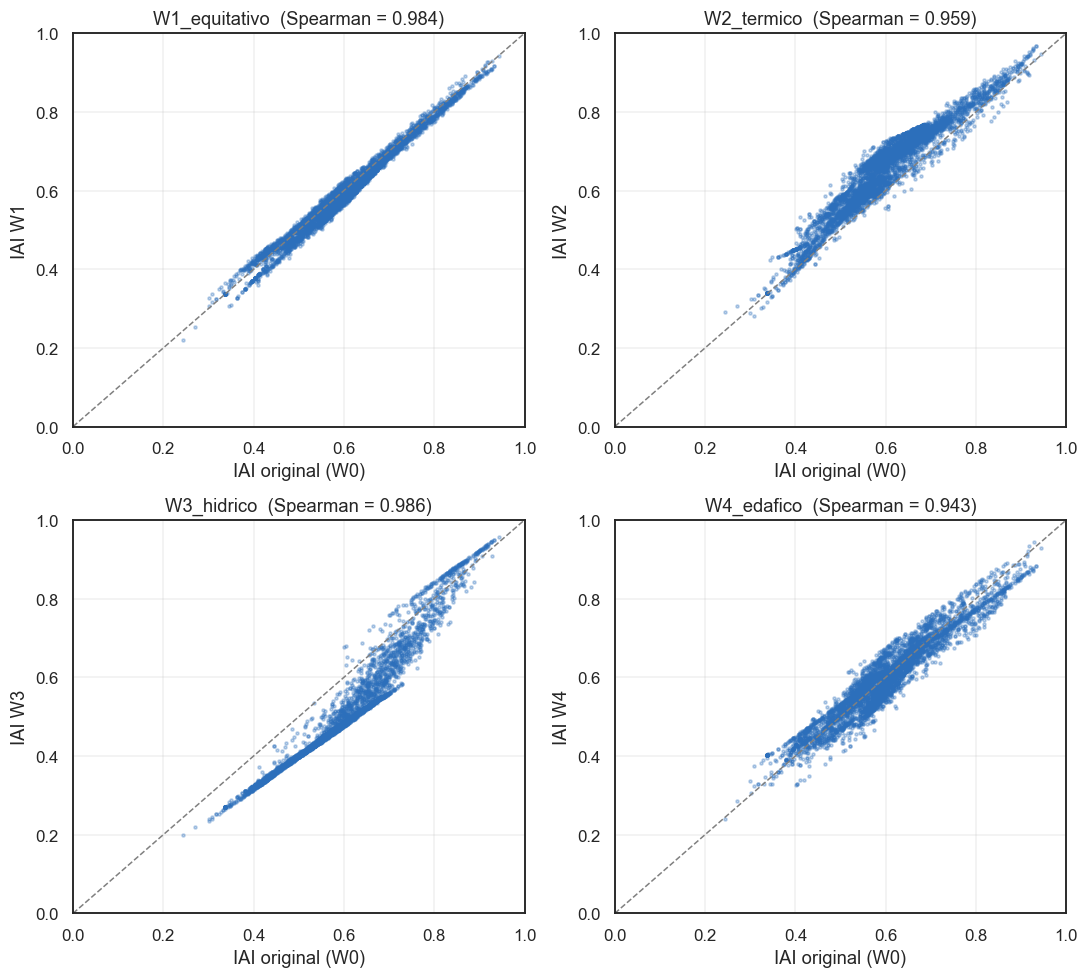

In [18]:
# Visualización: dispersión del IAI alternativo frente al original
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, nombre in zip(axes.flat, [n for n in CONFIGS if n != "W0_original"]):
    alt = df[f"IAI_{nombre}"].to_numpy()
    # Muestra para no saturar el gráfico
    idx = np.random.default_rng(42).choice(len(ref), size=min(5000, len(ref)), replace=False)
    ax.scatter(ref[idx], alt[idx], s=4, alpha=0.3, color="#2c6fbb")
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    r_spea, _ = spearmanr(ref, alt)
    ax.set_title(f"{nombre}  (Spearman = {r_spea:.3f})")
    ax.set_xlabel("IAI original (W0)")
    ax.set_ylabel(f"IAI {nombre.split('_')[0]}")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("sensibilidad_dispersion.png", dpi=150, bbox_inches="tight")
plt.show()

## Prueba 2 — Estabilidad del ranking de cultivos

Se calcula el IAI medio de cada cultivo bajo cada configuración y se comprueba si el orden de idoneidad se conserva, mediante la correlación de rangos de Spearman.

In [19]:
# IAI medio por cultivo, para cada configuración
ranking = (
    df.group_by(COL_CULTIVO)
      .agg([pl.col(f"IAI_{n}").mean().alias(n) for n in CONFIGS])
      .sort("W0_original", descending=True)
)

# Opcional: añadir el nombre del cultivo si tienes el diccionario
try:
    from utils import CROP_DICT
    ranking = ranking.with_columns(
        pl.col(COL_CULTIVO).replace_strict(CROP_DICT, default="?").alias("nombre")
    )
except Exception:
    pass

print("IAI medio por cultivo (ordenado por config. original):")
print(ranking)


IAI medio por cultivo (ordenado por config. original):
shape: (12, 6)
┌─────────┬─────────────┬───────────────┬────────────┬────────────┬────────────┐
│ crop_id ┆ W0_original ┆ W1_equitativo ┆ W2_termico ┆ W3_hidrico ┆ W4_edafico │
│ ---     ┆ ---         ┆ ---           ┆ ---        ┆ ---        ┆ ---        │
│ i64     ┆ f64         ┆ f64           ┆ f64        ┆ f64        ┆ f64        │
╞═════════╪═════════════╪═══════════════╪════════════╪════════════╪════════════╡
│ 204     ┆ 0.665279    ┆ 0.654209      ┆ 0.729159   ┆ 0.563638   ┆ 0.661302   │
│ 75      ┆ 0.659715    ┆ 0.647358      ┆ 0.723486   ┆ 0.574009   ┆ 0.642591   │
│ 76      ┆ 0.654105    ┆ 0.64082       ┆ 0.718907   ┆ 0.573012   ┆ 0.632164   │
│ 221     ┆ 0.651313    ┆ 0.657647      ┆ 0.671706   ┆ 0.58641    ┆ 0.662761   │
│ 36      ┆ 0.600457    ┆ 0.588595      ┆ 0.664028   ┆ 0.504704   ┆ 0.59279    │
│ 54      ┆ 0.571923    ┆ 0.574019      ┆ 0.611407   ┆ 0.482181   ┆ 0.578504   │
│ 24      ┆ 0.567987    ┆ 0.548263     

In [20]:
# Correlación de rangos entre el orden original y cada alternativo
orden_ref = ranking["W0_original"].to_numpy()

filas_p2 = []
for nombre in CONFIGS:
    if nombre == "W0_original":
        continue
    orden_alt = ranking[nombre].to_numpy()
    rho, _ = spearmanr(orden_ref, orden_alt)
    filas_p2.append({"config": nombre, "spearman_ranking": rho})
    print(f"  {nombre:16s} | Spearman rangos = {rho:.4f}")

df_p2 = pl.DataFrame(filas_p2)

  W1_equitativo    | Spearman rangos = 0.9371
  W2_termico       | Spearman rangos = 0.9930
  W3_hidrico       | Spearman rangos = 0.9371
  W4_edafico       | Spearman rangos = 0.9161


 ### Prueba 3 — Estabilidad del perfil de idoneidad por región

Se verifica si el cultivo más idóneo de cada región biofísica se mantiene al variar la ponderación. La regionalización en sí no cambia, porque el clustering se construye sobre las variables biofísicas y no sobre el IAI.

In [21]:
if COL_CLUSTER in df.columns:
    print("Cultivo más idóneo por región y configuración:\n")
    for cl in sorted(df[COL_CLUSTER].unique().to_list()):
        sub = df.filter(pl.col(COL_CLUSTER) == cl)
        tops = []
        for nombre in CONFIGS:
            top_id = (
                sub.group_by(COL_CULTIVO)
                   .agg(pl.col(f"IAI_{nombre}").mean().alias("m"))
                   .sort("m", descending=True)
                   .head(1)[COL_CULTIVO][0]
            )
            tops.append(f"{nombre.split('_')[0]}={top_id}")
        print(f"  Cluster {cl}: " + " | ".join(tops))
else:
    print("No se encontró la columna de cluster; se omite la Prueba 3.")


No se encontró la columna de cluster; se omite la Prueba 3.


## Tabla resumen y veredicto

Se consolidan los resultados y se interpretan según la magnitud de las correlaciones. No se aplica un umbral rígido: se atiende a la convención de que correlaciones por encima de 0,8 reflejan una asociación muy fuerte y valores próximos a 1 una correspondencia casi perfecta.

In [22]:
# Consolidar Prueba 1 y Prueba 2
resumen = df_p1.join(df_p2, on="config")
print("Resumen del análisis de sensibilidad:")
print(resumen)

spearman_min = df_p1["spearman"].min()
print(f"\nSpearman mínimo del IAI: {spearman_min:.4f}")


Resumen del análisis de sensibilidad:
shape: (4, 4)
┌───────────────┬──────────┬──────────┬──────────────────┐
│ config        ┆ pearson  ┆ spearman ┆ spearman_ranking │
│ ---           ┆ ---      ┆ ---      ┆ ---              │
│ str           ┆ f64      ┆ f64      ┆ f64              │
╞═══════════════╪══════════╪══════════╪══════════════════╡
│ W1_equitativo ┆ 0.990252 ┆ 0.984037 ┆ 0.937063         │
│ W2_termico    ┆ 0.958763 ┆ 0.959058 ┆ 0.993007         │
│ W3_hidrico    ┆ 0.9615   ┆ 0.985898 ┆ 0.937063         │
│ W4_edafico    ┆ 0.957479 ┆ 0.942663 ┆ 0.916084         │
└───────────────┴──────────┴──────────┴──────────────────┘

Spearman mínimo del IAI: 0.9427


## EDA2: IAI Vs variables 

In [23]:
# ------------------------------------------------------------
# Estilo visual académico (paleta consistente con la memoria)
# ------------------------------------------------------------
COLOR_MAIN   = "#2e5b94"   # azul principal
COLOR_GREEN  = "#4a7c59"   # verde
COLOR_GRAY   = "#6b6b6b"   # gris
COLOR_ORANGE = "#d98c3f"   # naranja (acentos)
PALETA = [COLOR_MAIN, COLOR_GREEN, COLOR_GRAY, COLOR_ORANGE,
          "#7098c4", "#8ab08f", "#a88b6b", "#b5651d",
          "#3d6b52", "#264d7a", "#9a9a9a", "#c47f3d"]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

# Mostrar todas las filas y columnas sin truncar
pl.Config.set_tbl_rows(-1)        # todas las filas (-1 = sin límite)
pl.Config.set_tbl_cols(-1)        # todas las columnas
pl.Config.set_fmt_str_lengths(100)  # no cortar strings largos
pl.Config.set_tbl_width_chars(200)  # ancho total de la tabla


polars.config.Config

In [24]:
df = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v2.parquet")

In [25]:
# ------------------------------------------------------------
# Definición de grupos de variables
# ------------------------------------------------------------
vars_clima = ["tmax", "tmin", "ppt", "vpdmax", "vpdmin"]
vars_suelo = ["ph1to1h2o_r", "awc_r", "claytotal_r",
              "sandtotal_r", "silttotal_r", "dbthirdbar_r"]
vars_base  = vars_clima + vars_suelo
subindices = ["I_GDD", "I_temp", "I_precip", "I_suelo"]

# Etiquetas legibles para los gráficos
NOMBRES = {
    "tmax": "Temp. máxima (°C)", "tmin": "Temp. mínima (°C)",
    "ppt": "Precipitación (mm)", "vpdmax": "VPD máx (hPa)",
    "vpdmin": "VPD mín (hPa)", "ph1to1h2o_r": "pH del suelo",
    "awc_r": "Cap. agua disp. (cm/cm)", "claytotal_r": "Arcilla (%)",
    "sandtotal_r": "Arena (%)", "silttotal_r": "Limo (%)",
    "dbthirdbar_r": "Densidad aparente (g/cm³)",
    "I_GDD": "I_GDD (térmico)", "I_temp": "I_temp",
    "I_precip": "I_precip", "I_suelo": "I_suelo", "IAI": "IAI",
}

# Verificar que las columnas existen
faltantes = [c for c in vars_base + subindices + ["IAI"] if c not in df.columns]
print("Columnas faltantes:", faltantes if faltantes else "ninguna")

Columnas faltantes: ninguna


### IAI frente a los subíndices

Media de cada subíndice:
shape: (1, 4)
┌──────────┬──────────┬──────────┬──────────┐
│ I_GDD    ┆ I_temp   ┆ I_precip ┆ I_suelo  │
│ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╡
│ 0.729885 ┆ 0.913091 ┆ 0.127594 ┆ 0.585606 │
└──────────┴──────────┴──────────┴──────────┘


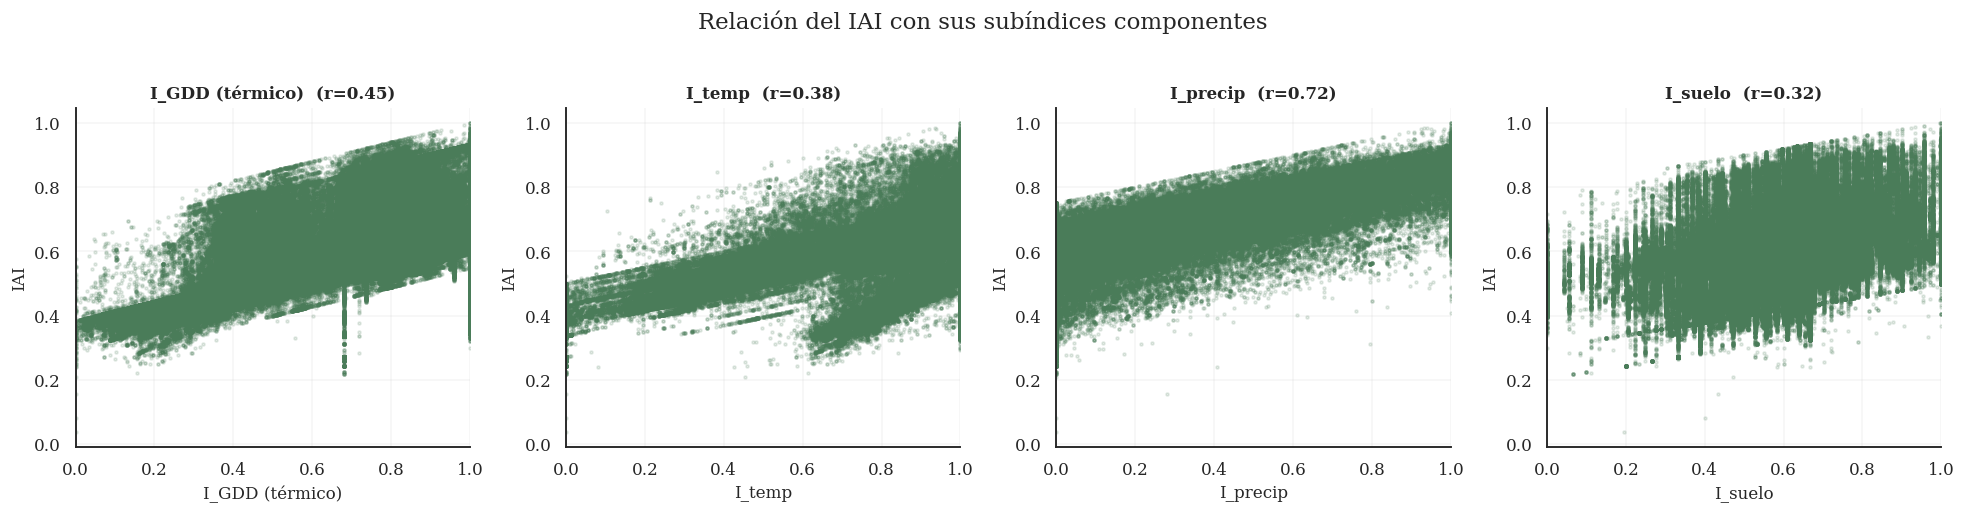

In [26]:
# Medias de los subíndices (identifica factores limitantes)
print("Media de cada subíndice:")
print(df.select(subindices).mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for i, sub in enumerate(subindices):
    ax = axes[i]
    x = df[sub].to_numpy()
    y = df["IAI"].to_numpy()
    ax.scatter(x, y, s=4, alpha=0.15, color=COLOR_GREEN)
    # correlación
    r = np.corrcoef(df[sub].to_numpy(), df["IAI"].to_numpy())[0, 1]
    ax.set_title(f"{NOMBRES.get(sub, sub)}  (r={r:.2f})", fontsize=11)
    ax.set_xlabel(NOMBRES.get(sub, sub))
    ax.set_ylabel("IAI")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.2)

plt.suptitle("Relación del IAI con sus subíndices componentes", fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_03_iai_vs_subindices.png"), dpi=300, bbox_inches="tight")
plt.show()

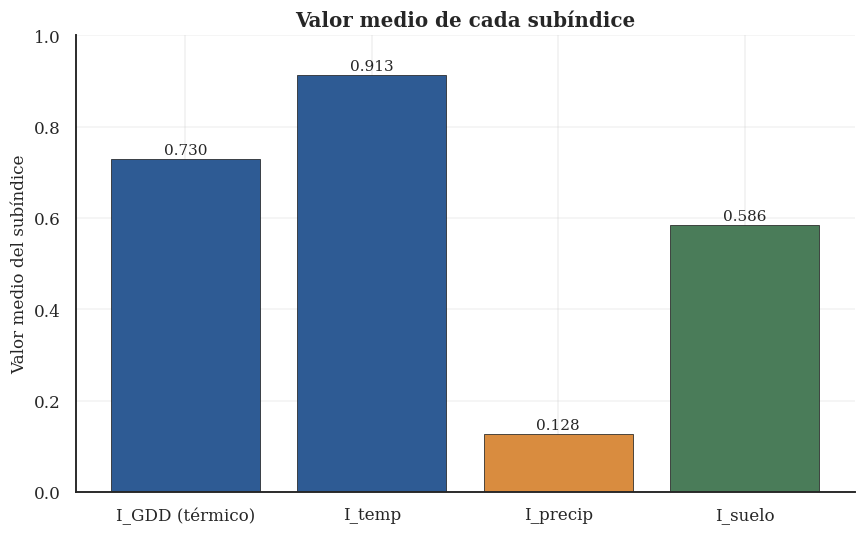

In [27]:
# Media de subíndices como gráfico de barras (visión de factores limitantes)
medias_sub = [df[s].mean() for s in subindices]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar([NOMBRES[s] for s in subindices], medias_sub,
                color=[COLOR_MAIN, COLOR_MAIN, COLOR_ORANGE, COLOR_GREEN],
                edgecolor="#222", linewidth=0.5)
for b, v in zip(barras, medias_sub):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", fontsize=10)
ax.set_ylabel("Valor medio del subíndice")
ax.set_ylim(0, 1)
ax.set_title("Valor medio de cada subíndice")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_04_medias_subindices.png"), dpi=300, bbox_inches="tight")
plt.show()

### IAI frente a las variables base

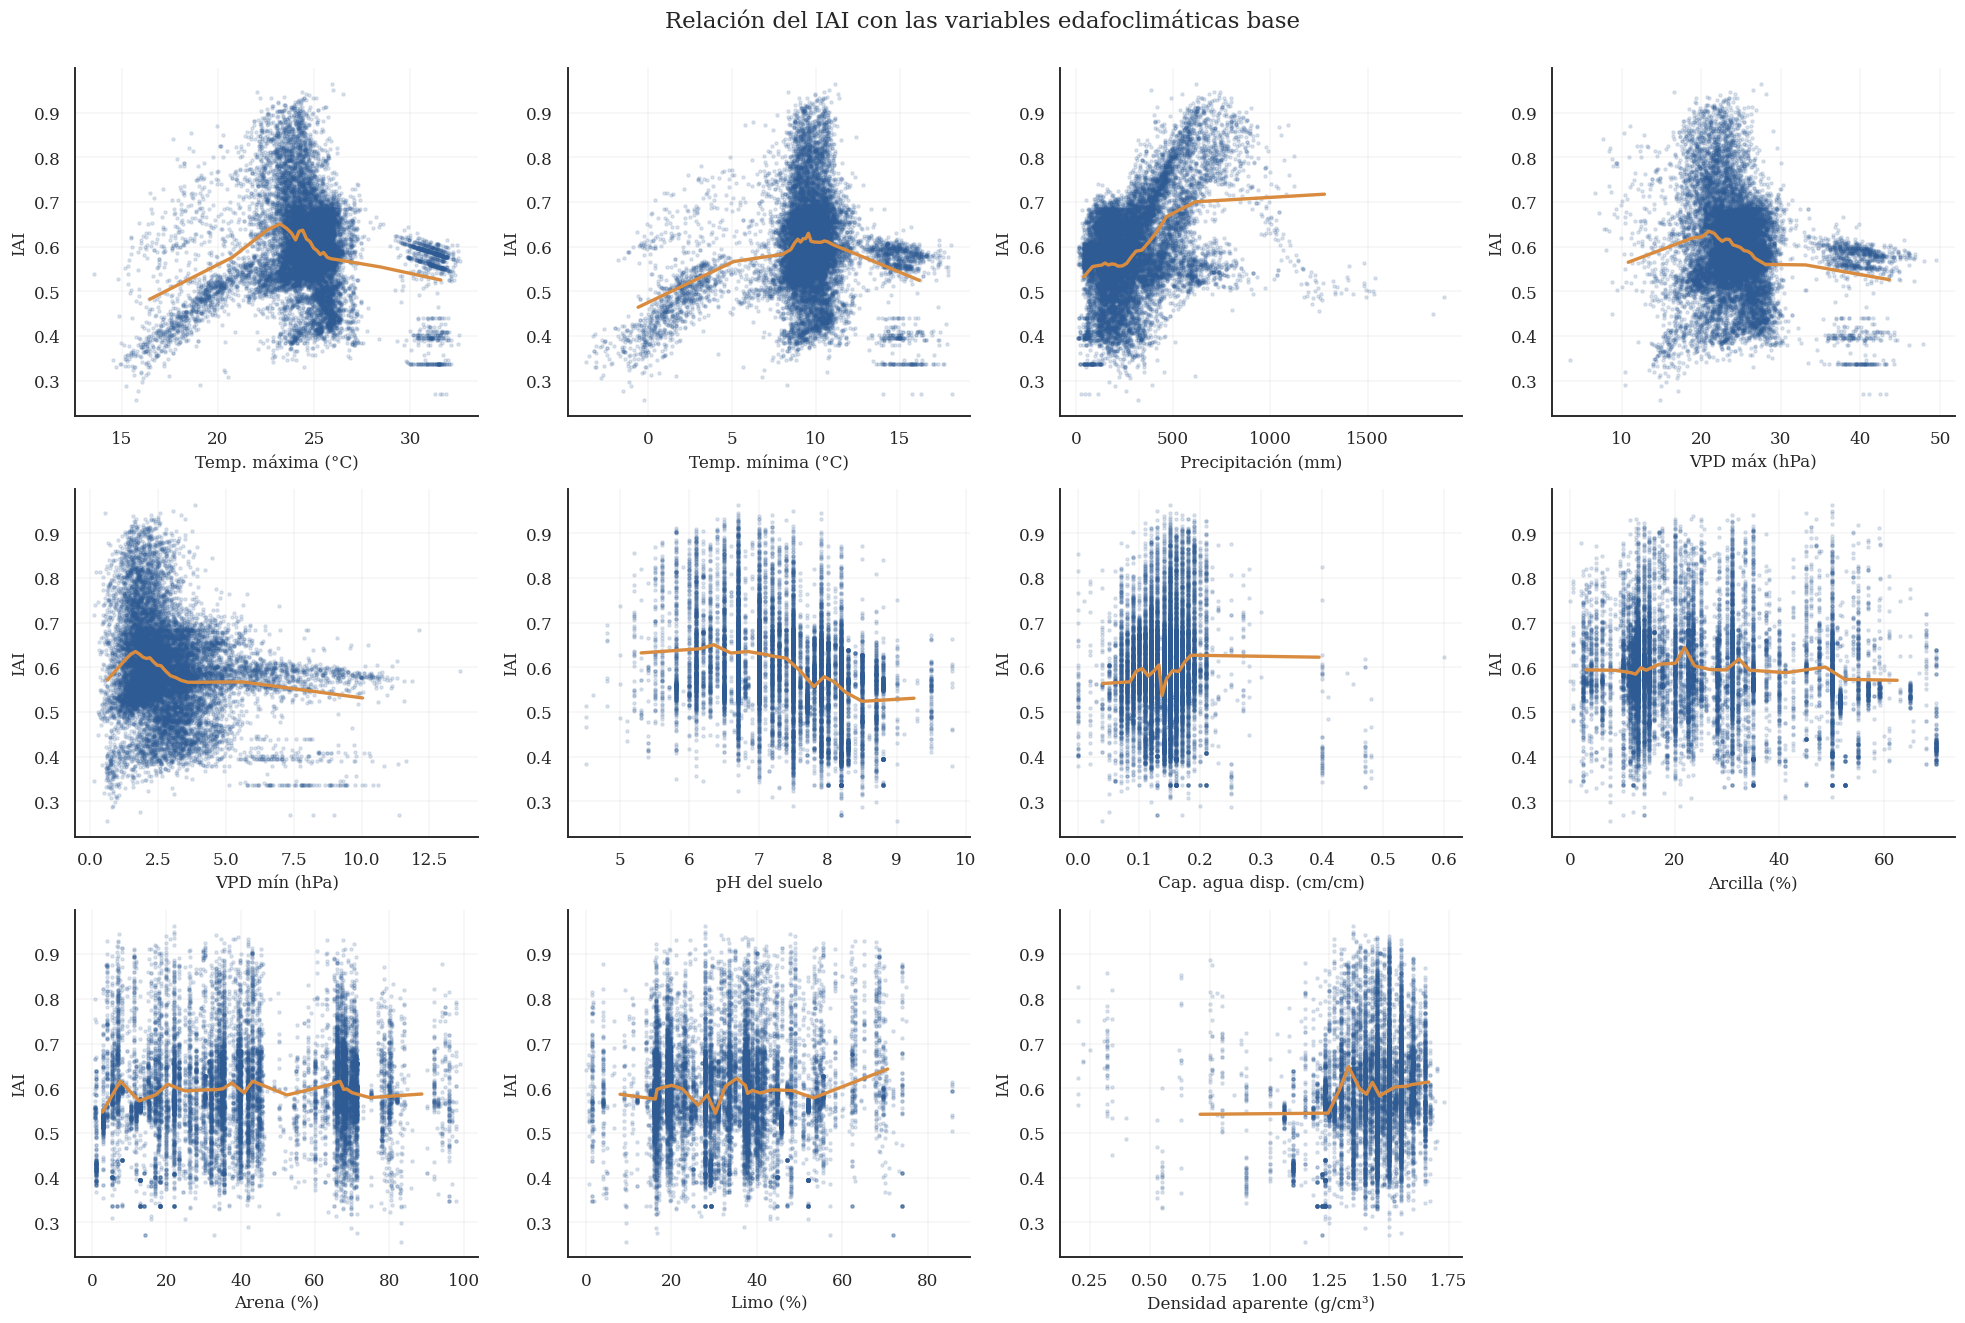

In [28]:
# Muestra para los scatter (eficiencia con datasets grandes)
np.random.seed(42)
n_muestra = min(15_000, df.shape[0])
idx = np.random.choice(df.shape[0], size=n_muestra, replace=False)
df_s = df[idx]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(vars_base):
    ax = axes[i]
    x = df_s[var].to_numpy()
    y = df_s["IAI"].to_numpy()
    ax.scatter(x, y, s=4, alpha=0.15, color=COLOR_MAIN)

    # Línea de tendencia (media de IAI por percentiles de x)
    try:
        bins = np.percentile(x, np.linspace(0, 100, 21))
        bins = np.unique(bins)
        centros, medias = [], []
        for j in range(len(bins) - 1):
            m = (x >= bins[j]) & (x < bins[j + 1])
            if m.sum() > 0:
                centros.append((bins[j] + bins[j + 1]) / 2)
                medias.append(y[m].mean())
        ax.plot(centros, medias, color=COLOR_ORANGE, linewidth=2.2)
    except Exception:
        pass

    ax.set_xlabel(NOMBRES.get(var, var))
    ax.set_ylabel("IAI")
    ax.grid(alpha=0.2)

# Ocultar ejes sobrantes
for k in range(len(vars_base), len(axes)):
    axes[k].set_visible(False)

plt.suptitle("Relación del IAI con las variables edafoclimáticas base",
             fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_02_iai_vs_variables.png"), dpi=300, bbox_inches="tight")
plt.show()

Temperatura (máxima y mínima): ambas muestran una relación en forma de joroba, con un punto óptimo (alrededor de 23–25 °C en la máxima) a partir del cual la idoneidad empieza a caer. Es el comportamiento esperado: ni el frío ni el calor extremo favorecen a los cultivos.
Precipitación: es de las relaciones más marcadas. El IAI sube con fuerza a medida que aumenta la lluvia y se estabiliza a partir de los 500–600 mm. Esto confirma que el agua es un factor clave en California, donde la escasez de precipitación limita buena parte del territorio.
VPD (déficit de presión de vapor): tienen una relación inversa, cuanto mayor es el estrés evaporativo, menor es la idoneidad
Variables de suelo (pH, textura, densidad): su efecto es más suave y difuso. La línea se mantiene bastante plana, lo que indica que el suelo influye menos que el clima sobre el IAI global, aunque el pH muestra una ligera preferencia por valores cercanos a la neutralidad.

### Correlación

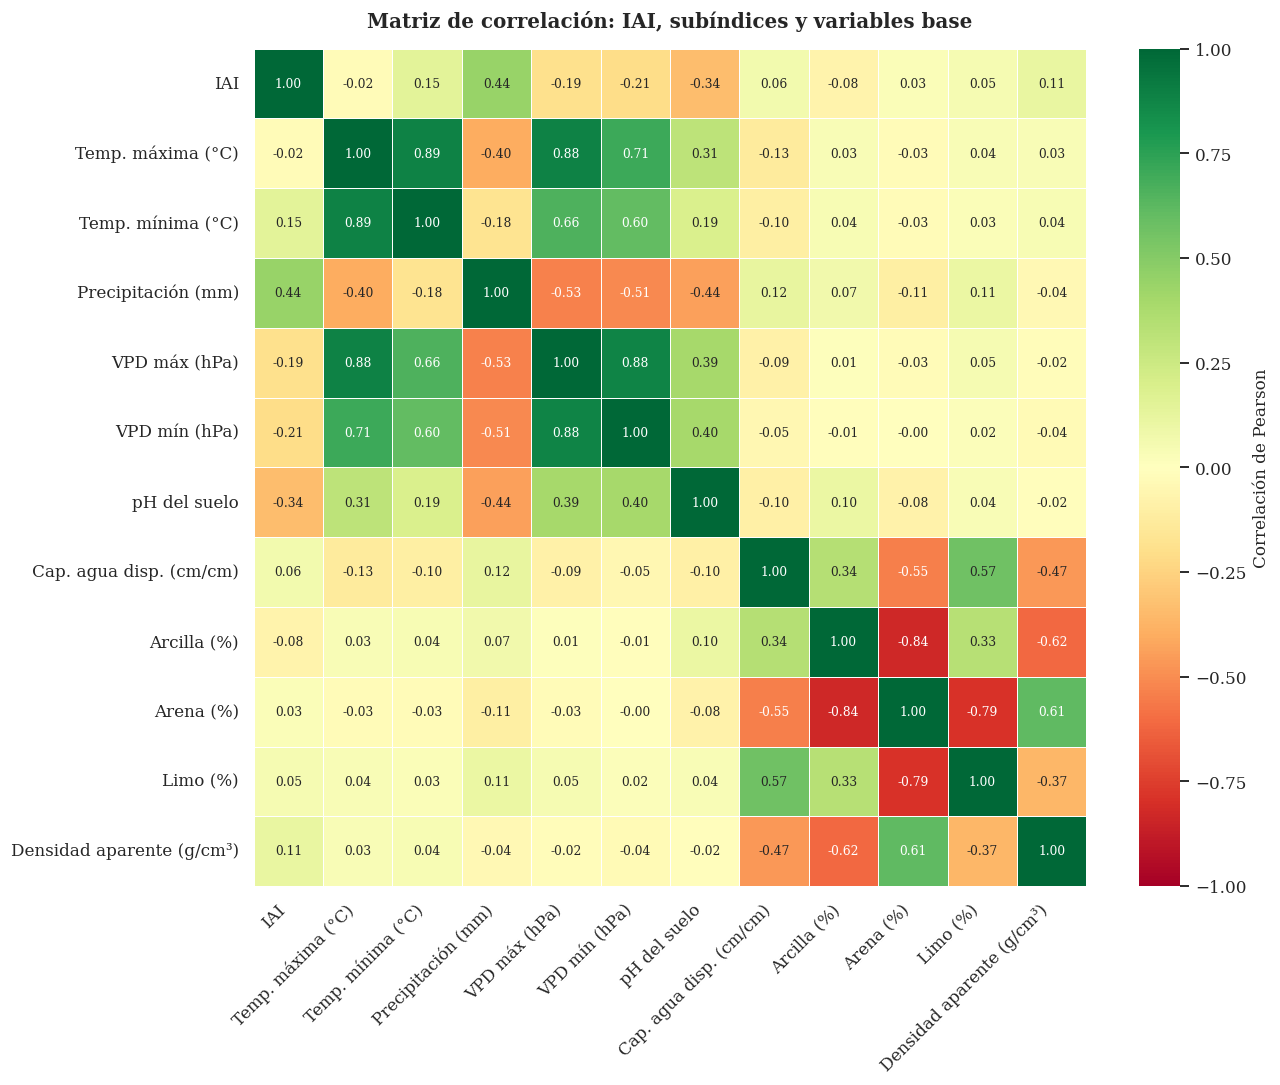

In [29]:
# Matriz de correlación
cols_corr = ["IAI"]  + vars_base
M = df.select(cols_corr).to_numpy()
corr = np.corrcoef(M, rowvar=False)

etiquetas = [NOMBRES.get(c, c) for c in cols_corr]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, ax=ax, cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Matriz de correlación: IAI, subíndices y variables base", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_06_matriz_correlacion.png"), dpi=300, bbox_inches="tight")
plt.show()

In [30]:
# Variables a evaluar contra el IAI
vars_eval = subindices + vars_base
y = df["IAI"].to_numpy()

# Muestra para eficiencia (MI es costoso en 633k filas)
np.random.seed(42)
n = min(50_000, df.shape[0])
idx = np.random.choice(df.shape[0], size=n, replace=False)
y_s = y[idx]

resultados = []
for var in vars_eval:
    x = df[var].to_numpy()
    x_s = x[idx]

    # Pearson (lineal)
    pearson = np.corrcoef(x, y)[0, 1]

    # Spearman (monótona)
    spear = spearmanr(x, y).correlation

    # Información mutua (cualquier relación, normalizada a [0,~])
    mi = mutual_info_regression(x_s.reshape(-1, 1), y_s,
                                 random_state=42)[0]

    resultados.append({
        "variable": NOMBRES.get(var, var),
        "pearson": round(pearson, 3),
        "spearman": round(spear, 3),
        "info_mutua": round(mi, 3),
    })

df_corr = pl.DataFrame(resultados).sort("info_mutua", descending=True)
print(df_corr)

shape: (15, 4)
┌───────────────────────────┬─────────┬──────────┬────────────┐
│ variable                  ┆ pearson ┆ spearman ┆ info_mutua │
│ ---                       ┆ ---     ┆ ---      ┆ ---        │
│ str                       ┆ f64     ┆ f64      ┆ f64        │
╞═══════════════════════════╪═════════╪══════════╪════════════╡
│ I_GDD (térmico)           ┆ 0.455   ┆ 0.412    ┆ 1.338      │
│ I_suelo                   ┆ 0.32    ┆ 0.314    ┆ 0.713      │
│ Temp. máxima (°C)         ┆ -0.024  ┆ -0.088   ┆ 0.64       │
│ Precipitación (mm)        ┆ 0.442   ┆ 0.378    ┆ 0.513      │
│ I_precip                  ┆ 0.718   ┆ 0.639    ┆ 0.454      │
│ Arena (%)                 ┆ 0.027   ┆ 0.049    ┆ 0.453      │
│ I_temp                    ┆ 0.382   ┆ 0.301    ┆ 0.446      │
│ Limo (%)                  ┆ 0.047   ┆ 0.011    ┆ 0.444      │
│ Temp. mínima (°C)         ┆ 0.146   ┆ 0.098    ┆ 0.427      │
│ VPD máx (hPa)             ┆ -0.193  ┆ -0.157   ┆ 0.395      │
│ pH del suelo           

Para complementar la correlación de Pearson que solo mide relaciones lineales, se calcularon también la correlación de Spearman (relaciones monótonas) y la información mutua (cualquier tipo de dependencia, lineal o no). Con esto tenemos un overview del panorama más amplio ya que como vimos en los graficos las variables no tienen una relación lineal con IAI.

- El caso de la temperatura máxima muestra la importancia de usar la información mutua, ya que mientras que su correlación de Pearson es prácticamente nula (-0.01), su información mutua es una de las más altas (0.64). 


### IAI por cultivo

In [31]:
# IAI medio por cultivo (tabla)
resumen_cultivo = (
    df.group_by("crop_name")
      .agg([
          pl.col("IAI").mean().alias("IAI_medio"),
          pl.col("IAI").median().alias("IAI_mediana"),
          pl.col("IAI").std().alias("IAI_std"),
          pl.len().alias("n"),
      ])
      .sort("IAI_medio", descending=True)
)
print(resumen_cultivo)

shape: (12, 5)
┌──────────────┬───────────┬─────────────┬──────────┬────────┐
│ crop_name    ┆ IAI_medio ┆ IAI_mediana ┆ IAI_std  ┆ n      │
│ ---          ┆ ---       ┆ ---         ┆ ---      ┆ ---    │
│ str          ┆ f64       ┆ f64         ┆ f64      ┆ u32    │
╞══════════════╪═══════════╪═════════════╪══════════╪════════╡
│ Pistachios   ┆ 0.665279  ┆ 0.654005    ┆ 0.073125 ┆ 38503  │
│ Almonds      ┆ 0.659715  ┆ 0.639317    ┆ 0.086684 ┆ 136199 │
│ Walnuts      ┆ 0.654105  ┆ 0.623856    ┆ 0.087098 ┆ 42355  │
│ Strawberries ┆ 0.651313  ┆ 0.623379    ┆ 0.100055 ┆ 2117   │
│ Alfalfa      ┆ 0.600457  ┆ 0.602514    ┆ 0.114394 ┆ 136325 │
│ Tomatoes     ┆ 0.571923  ┆ 0.552586    ┆ 0.085331 ┆ 26379  │
│ Wheat        ┆ 0.567987  ┆ 0.550403    ┆ 0.123856 ┆ 76469  │
│ Grapes       ┆ 0.565073  ┆ 0.557102    ┆ 0.06373  ┆ 83068  │
│ Rice         ┆ 0.553218  ┆ 0.551954    ┆ 0.028901 ┆ 51469  │
│ Oranges      ┆ 0.462899  ┆ 0.463185    ┆ 0.026316 ┆ 10663  │
│ Cotton       ┆ 0.428301  ┆ 0.421076   

C:\Users\lesli\AppData\Local\Temp\ipykernel_26452\1288147232.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box, labels=orden, patch_artist=True,


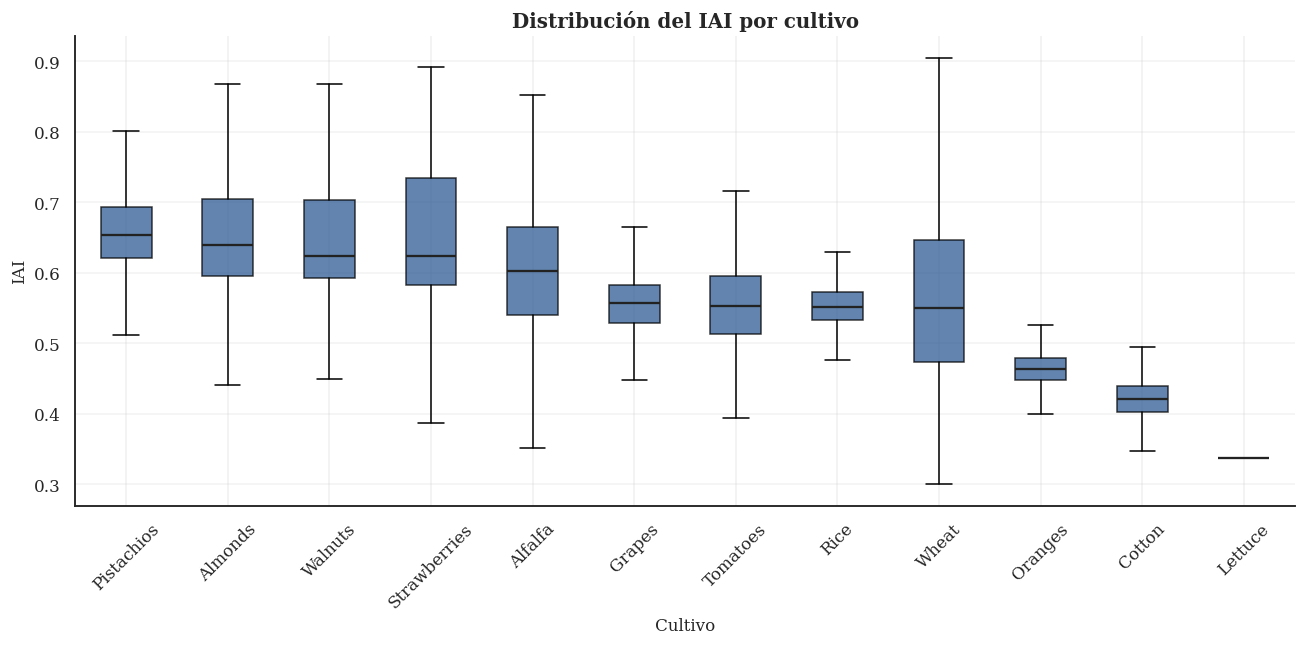

In [32]:
# Boxplot del IAI por cultivo, ordenado por mediana
orden = (df.group_by("crop_name")
           .agg(pl.col("IAI").median().alias("m"))
           .sort("m", descending=True)["crop_name"].to_list())

datos_box = [df.filter(pl.col("crop_name") == c)["IAI"].to_numpy() for c in orden]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(datos_box, labels=orden, patch_artist=True,
                showfliers=False, medianprops=dict(color="#222", linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_MAIN)
    patch.set_alpha(0.75)
ax.set_ylabel("IAI")
ax.set_xlabel("Cultivo")
ax.set_title("Distribución del IAI por cultivo")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_05_iai_por_cultivo.png"), dpi=300, bbox_inches="tight")
plt.show()

In [33]:
import polars as pl

# Cargar ambas versiones
iai_v1 = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai.parquet")
iai_v2 = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v2.parquet")

CROP_ES = {
    75: "Almendras", 69: "Uvas", 204: "Pistachos", 76: "Nueces",
    54: "Tomates", 3: "Arroz", 221: "Fresas", 212: "Naranjas",
    36: "Alfalfa", 24: "Trigo", 227: "Lechuga", 2: "Algodón",
}

# IAI medio por cultivo en cada versión
v1 = iai_v1.group_by("crop_id").agg(pl.col("IAI").mean().alias("iai_v1"))
v2 = iai_v2.group_by("crop_id").agg(pl.col("IAI").mean().alias("iai_v2"))

comparacion = (
    v1.join(v2, on="crop_id")
    .with_columns([
        (pl.col("iai_v2") - pl.col("iai_v1")).alias("cambio"),
        pl.col("crop_id").replace_strict(CROP_ES).alias("cultivo"),
    ])
    .select(["cultivo", "iai_v1", "iai_v2", "cambio"])
    .sort("cambio")
    .with_columns(pl.col(pl.Float64).round(4))
)

with pl.Config(tbl_rows=20):
    print(comparacion)

# Resumen
print(f"\nCambio medio: {comparacion['cambio'].mean():.4f}")
print(f"Cultivos que bajan: {comparacion.filter(pl.col('cambio') < 0).height}")
print(f"Cultivos que suben: {comparacion.filter(pl.col('cambio') > 0).height}")

shape: (12, 4)
┌───────────┬────────┬────────┬─────────┐
│ cultivo   ┆ iai_v1 ┆ iai_v2 ┆ cambio  │
│ ---       ┆ ---    ┆ ---    ┆ ---     │
│ str       ┆ f64    ┆ f64    ┆ f64     │
╞═══════════╪════════╪════════╪═════════╡
│ Lechuga   ┆ 0.448  ┆ 0.3552 ┆ -0.0927 │
│ Fresas    ┆ 0.6542 ┆ 0.6513 ┆ -0.0029 │
│ Naranjas  ┆ 0.4634 ┆ 0.4629 ┆ -0.0006 │
│ Tomates   ┆ 0.5721 ┆ 0.5719 ┆ -0.0002 │
│ Uvas      ┆ 0.5652 ┆ 0.5651 ┆ -0.0001 │
│ Trigo     ┆ 0.568  ┆ 0.568  ┆ -0.0    │
│ Almendras ┆ 0.6597 ┆ 0.6597 ┆ -0.0    │
│ Algodón   ┆ 0.4283 ┆ 0.4283 ┆ -0.0    │
│ Pistachos ┆ 0.6653 ┆ 0.6653 ┆ -0.0    │
│ Nueces    ┆ 0.6541 ┆ 0.6541 ┆ -0.0    │
│ Alfalfa   ┆ 0.6005 ┆ 0.6005 ┆ 0.0     │
│ Arroz     ┆ 0.5532 ┆ 0.5532 ┆ 0.0     │
└───────────┴────────┴────────┴─────────┘

Cambio medio: -0.0080
Cultivos que bajan: 5
Cultivos que suben: 0


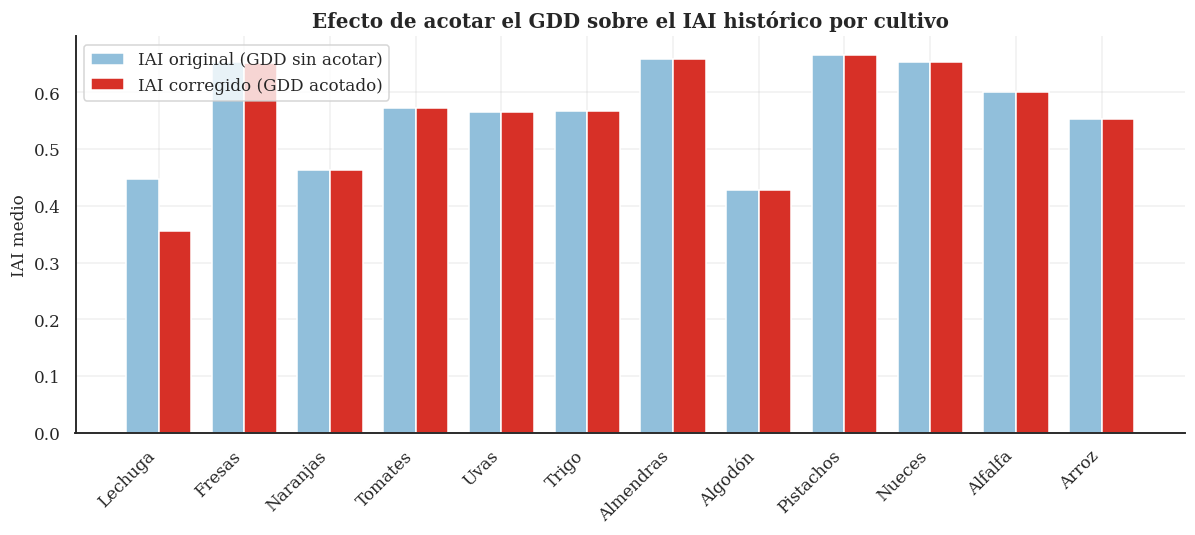

In [34]:
import matplotlib.pyplot as plt
import numpy as np

comp_pd = comparacion.to_pandas()
x = np.arange(len(comp_pd))
ancho = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - ancho/2, comp_pd["iai_v1"], ancho, label="IAI original (GDD sin acotar)", color="#91bfdb")
ax.bar(x + ancho/2, comp_pd["iai_v2"], ancho, label="IAI corregido (GDD acotado)", color="#d73027")
ax.set_xticks(x)
ax.set_xticklabels(comp_pd["cultivo"], rotation=45, ha="right")
ax.set_ylabel("IAI medio")
ax.set_title("Efecto de acotar el GDD sobre el IAI histórico por cultivo")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("comparacion_iai_gdd.pdf", bbox_inches="tight")
plt.show()